# Seabed lithology — raw vs STAC folder vs cloud

Checks that the seabed lithology raster is the same in the three places it lives:

1. **Raw**: `P:\...\Data_Vivian\seabed_litho.tif` (original GeoTIFF)
2. **STAC folder**: `P:\...\Data_Vivian\stac\seabed_litho\cog\seabed_litho.tif` (COG produced by `notebooks/17_seabed_litho.ipynb`)
3. **Cloud**: the COG found through the public STAC catalog (`gca-stac-7`, collection `seabed_lithology`)

The three rasters are plotted side by side and compared pixel by pixel (shape, CRS, transform, dtype, nodata, class counts).

Environment: `environment_exploration.yml` (Miniforge).

In [1]:
from pathlib import Path
from posixpath import join as urljoin

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pystac_client
import rasterio
from matplotlib.colors import BoundaryNorm, ListedColormap

## 1) Locations

In [2]:
data_vivian = Path(r"P:\11209117-041-ipdc-egypt-swi\data\IntDeltaPlatform_QGA\Data_Vivian")
raw_path = data_vivian / "seabed_litho.tif"
stac_folder_path = data_vivian / "stac" / "seabed_litho" / "cog" / "seabed_litho.tif"

gcs_protocol = "https://storage.googleapis.com"
catalog_url = urljoin(gcs_protocol, "gca-data-public", "gca", "gca-stac-7", "catalog.json")
collection_id = "seabed_lithology"

for p in (raw_path, stac_folder_path):
    print(p.is_file(), p)

True P:\11209117-041-ipdc-egypt-swi\data\IntDeltaPlatform_QGA\Data_Vivian\seabed_litho.tif
True P:\11209117-041-ipdc-egypt-swi\data\IntDeltaPlatform_QGA\Data_Vivian\stac\seabed_litho\cog\seabed_litho.tif


## 2) Find the data through the STAC catalog

In [3]:
catalog = pystac_client.Client.open(catalog_url)
collection = catalog.get_collection(collection_id)
if collection is None:
    raise LookupError(f"Collection {collection_id} not found in {catalog_url}")

items = list(collection.get_items())
print("Collection:", collection.id, "|", collection.title)
print("Items:", [i.id for i in items])

item = items[0]
cloud_href = item.assets["data"].href
print("Cloud COG:", cloud_href)
print("Item bbox:", item.bbox)
print("Raster bands:", item.assets["data"].extra_fields.get("raster:bands"))

c:\Users\fuentesm\AppData\Local\miniforge3\envs\gca-exploration\Lib\site-packages\pystac_client\client.py:191: NoConformsTo: Server does not advertise any conformance classes.
  warnings.warn(NoConformsTo())
c:\Users\fuentesm\AppData\Local\miniforge3\envs\gca-exploration\Lib\site-packages\pystac_client\client.py:410: FallbackToPystac: Falling back to pystac. This might be slow.
  self._warn_about_fallback("COLLECTIONS", "FEATURES")


Collection: seabed_lithology | Seafloor sediments in the world's ocean
Items: ['seabed_litho.tif']
Cloud COG: https://storage.googleapis.com/gca-data-public/gca/seabed_lithology/seabed_litho.tif
Item bbox: [-180.0, -90.0, 180.0, 90.0]
Raster bands: [{'nodata': -32768, 'data_type': 'int16', 'spatial_resolution': 0.1}]


c:\Users\fuentesm\AppData\Local\miniforge3\envs\gca-exploration\Lib\site-packages\pystac_client\collection_client.py:149: FallbackToPystac: Falling back to pystac. This might be slow.
  root._warn_about_fallback("ITEM_SEARCH")


## 3) Read the three rasters

In [4]:
sources = {
    "raw (P:)": str(raw_path),
    "stac folder (P:)": str(stac_folder_path),
    "cloud (catalog)": cloud_href,
}

arrays, profiles = {}, {}
for name, path in sources.items():
    with rasterio.open(path) as src:
        arrays[name] = src.read(1)
        profiles[name] = {
            "shape": src.shape,
            "dtype": src.dtypes[0],
            "nodata": src.nodata,
            "crs": src.crs.to_string(),
            "transform": tuple(round(v, 6) for v in src.transform)[:6],
            "tiled (COG)": src.is_tiled,
            "overviews": src.overviews(1),
            "compression": str(src.compression),
            "bounds": tuple(round(v, 3) for v in src.bounds),
        }

pd.DataFrame(profiles).T

,shape,dtype,nodata,crs,transform,tiled (COG),overviews,compression,bounds
raw (P:),"(1801, 3601)",int16,-32768.0,EPSG:4326,"(0.1, 0.0, -180.05, 0.0, -0.1, 90.05)",False,[],None,"(-180.05, -90.05, 180.05, 90.05)"
stac folder (P:),"(1801, 3601)",int16,-32768.0,EPSG:4326,"(0.1, 0.0, -180.05, 0.0, -0.1, 90.05)",True,"[2, 4, 8]",Compression.deflate,"(-180.05, -90.05, 180.05, 90.05)"
cloud (catalog),"(1801, 3601)",int16,-32768.0,EPSG:4326,"(0.1, 0.0, -180.05, 0.0, -0.1, 90.05)",True,"[2, 4, 8]",Compression.deflate,"(-180.05, -90.05, 180.05, 90.05)"


## 4) Plot

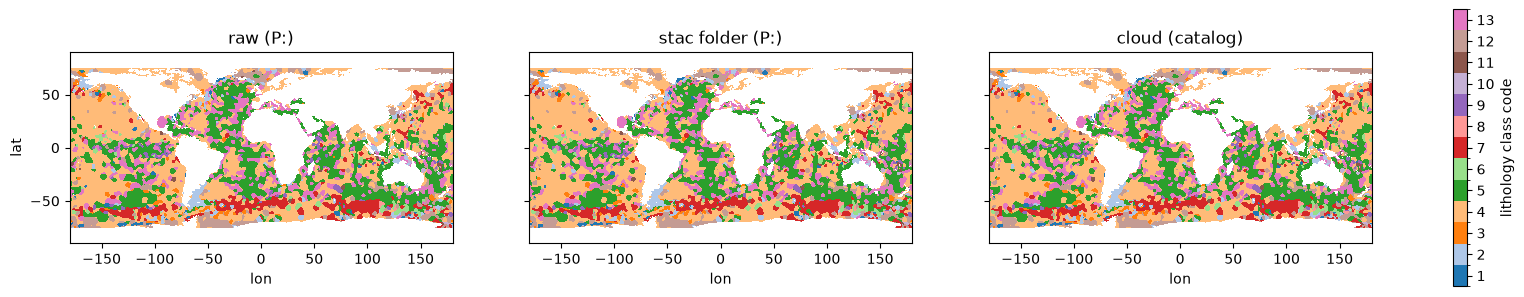

In [5]:
nodata = profiles["raw (P:)"]["nodata"]
classes = np.unique(arrays["raw (P:)"])
classes = classes[classes != nodata]

# One colour per class code (categorical data: no continuous colour scale)
cmap = ListedColormap(plt.get_cmap("tab20").colors[: len(classes)])
norm = BoundaryNorm(np.append(classes, classes.max() + 1) - 0.5, cmap.N)

fig, axes = plt.subplots(1, 3, figsize=(21, 4.5), sharex=True, sharey=True)
for ax, (name, arr) in zip(axes, arrays.items()):
    bounds = profiles[name]["bounds"]
    im = ax.imshow(
        np.ma.masked_equal(arr, nodata),
        cmap=cmap, norm=norm, interpolation="nearest",
        extent=(bounds[0], bounds[2], bounds[1], bounds[3]),
    )
    ax.set_title(name)
    ax.set_xlabel("lon")
axes[0].set_ylabel("lat")
fig.colorbar(im, ax=axes, ticks=classes, label="lithology class code", shrink=0.8)
plt.show()

## 5) Compare

In [6]:
# Pixels per class in each source
counts = pd.DataFrame(
    {name: pd.Series(*np.unique(arr, return_counts=True)[::-1]) for name, arr in arrays.items()}
).fillna(0).astype(int)
counts.index.name = "class code"
display(counts)

names = list(arrays)
ref = names[0]
results = []
for other in names[1:]:
    same_shape = arrays[ref].shape == arrays[other].shape
    n_diff = int((arrays[ref] != arrays[other]).sum()) if same_shape else None
    results.append({
        "comparison": f"{ref} vs {other}",
        "same shape": same_shape,
        "same CRS/transform": (profiles[ref]["crs"], profiles[ref]["transform"]) == (profiles[other]["crs"], profiles[other]["transform"]),
        "different pixels": n_diff,
        "identical": same_shape and n_diff == 0,
    })
display(pd.DataFrame(results))

if all(r["identical"] for r in results):
    print("OK: raw, stac folder and cloud contain exactly the same data.")
else:
    print("MISMATCH: see the table above.")

,raw (P:),stac folder (P:),cloud (catalog)
class code,,,
-32768,2707000,2707000,2707000
1,35547,35547,35547
2,134176,134176,134176
3,65033,65033,65033
4,1522140,1522140,1522140
5,900205,900205,900205
6,59417,59417,59417
7,260654,260654,260654
8,6287,6287,6287


,comparison,same shape,same CRS/transform,different pixels,identical
0,raw (P:) vs stac folder (P:),True,True,0,True
1,raw (P:) vs cloud (catalog),True,True,0,True


OK: raw, stac folder and cloud contain exactly the same data.


## 6) Call the WMS service

Requests the layer published in GeoServer (step 8 of `scripts/17_seabed_litho.ipynb`) through the `visual` asset of the STAC item, to check the service shows the same data. Needs access to the Deltares network. Colours come from the GeoServer style, so they will differ from the plots above.

WMS asset: https://international-delta-platform.avi.directory.intra/geoserver/wms/seabed_lithology | layer: seabed_lithology:seabed_litho


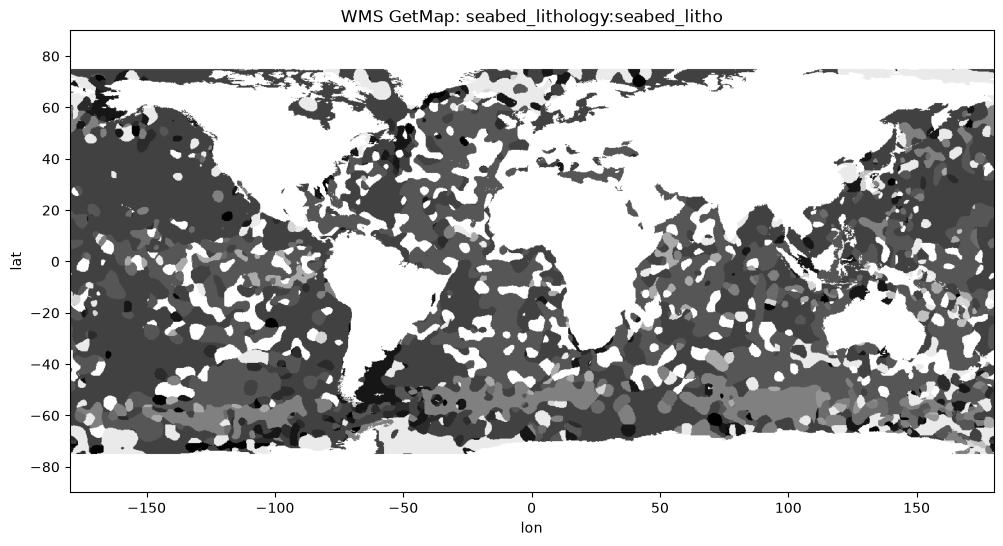

In [7]:
import io
import urllib3
import requests
import matplotlib.image as mpimg

urllib3.disable_warnings()  # the internal GeoServer uses a self-signed certificate

# WMS endpoint taken from the STAC item's "visual" asset (added by scripts/17_seabed_litho.ipynb)
wms_url = items[0].assets["visual"].href
layer = f"{collection_id}:seabed_litho"  # workspace:layer as published in step 8
print("WMS asset:", wms_url, "| layer:", layer)

params = dict(
    SERVICE="WMS", VERSION="1.1.1", REQUEST="GetMap", LAYERS=layer, STYLES="",
    SRS="EPSG:4326", BBOX="-180,-90,180,90", WIDTH=1440, HEIGHT=720,
    FORMAT="image/png", TRANSPARENT="true",
)
resp = requests.get(wms_url, params=params, verify=False, timeout=60)
resp.raise_for_status()
if not resp.headers.get("Content-Type", "").startswith("image"):
    raise RuntimeError(resp.text[:500])  # GeoServer returns XML on errors

img = mpimg.imread(io.BytesIO(resp.content), format="png")
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(img, extent=(-180, 180, -90, 90))
ax.set_title(f"WMS GetMap: {layer}")
ax.set_xlabel("lon"); ax.set_ylabel("lat")
plt.show()